# How does Charge vs. Discharge affect DVA

In [35]:
import os
import sys
import math
sys.path.append(os.path.join(os.getcwd().partition('EV_DVA_Robustness')[0], "EV_DVA_Robustness"))
from src.config_base import GeneralConfig

In [36]:
import pandas as pd
import numpy as np
import scipy as sp
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator, FixedLocator
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

In [37]:
from src.data.read_feather import ReadFeather
from src.filtering.filter_methods import FilterMethods
from src.voltage_capacity_analysis.ica import ICA
from src.voltage_capacity_analysis.dva import DVA
from src.visualization.config_visualization import VisualizationConfig, instantiate_matplotlib_parameters, cm2inch
instantiate_matplotlib_parameters()
from src.visualization.colormaps import ColorMaps

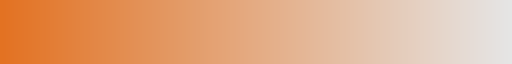

In [38]:
tum_orange_cmap = ColorMaps.orange_tum()
orange_colors = tum_orange_cmap(np.linspace(0,1, 3))
tum_orange_cmap

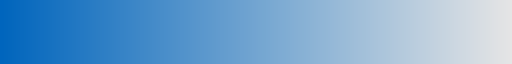

In [39]:
tum_blue_cmap = ColorMaps.blue_tum()
blue_colors = tum_blue_cmap(np.linspace(0,1, 5))
tum_blue_cmap

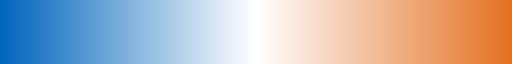

In [40]:
tum_cmap = ColorMaps.blue_orange_tum(grayscale=1)
colors = tum_cmap(np.linspace(1,0, 2))
tum_cmap

In [41]:
def filter_func_preprocess_U(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal.values[:,0]

In [42]:
def filter_func_preprocess_Q(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal

In [43]:
read_feather = ReadFeather()

In [44]:
read_feather.set_filter_U(filter_func_preprocess_U)
read_feather.set_filter_Q(filter_func_preprocess_Q)

## CU Data Cupra C10

In [45]:
%%capture
df_cupra_charge = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_10A_CEE16_C10.feather"), calc_E = True,lower_voltage=365, upper_voltage=450) 
df_cupra_discharge = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_C10_discharge.feather"), calc_E = True, lower_voltage=365, upper_voltage=450) 
df_cupra_discharge["Q"] = sp.integrate.cumtrapz(df_cupra_discharge["I"], df_cupra_discharge["time_h"], initial=0)
df_cupra_discharge["E"] = sp.integrate.cumtrapz(df_cupra_discharge["P"], df_cupra_discharge["time_h"], initial=0)

In [46]:
df_cupra_charge.P.mean()

6111.015011567655

In [47]:
df_cupra_discharge[df_cupra_discharge.I<-10].P.mean()

-5275.799316861263

In [48]:
df_cupra_discharge2 = df_cupra_discharge.copy()
df_cupra_discharge2.Q = sorted(df_cupra_discharge2.Q+np.max(np.abs(df_cupra_discharge2.Q)))
df_cupra_discharge2.U = sorted(df_cupra_discharge2.U)
#df_cupra_discharge2.SOC = sorted(df_cupra_discharge2.SOC)

In [49]:
df_merge_cupra = pd.merge_asof(left = df_cupra_charge, right = df_cupra_discharge2, on='Q', suffixes=('_left', '_right'))
df_merge_cupra["U_mean"] = (df_merge_cupra["U_left"]+df_merge_cupra["U_right"])/2

In [50]:
def filter_func_v(signal):
    perc_filter = 1 #% filter
    filtered_signal = FilterMethods().rolling_mean_numpy(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    filtered_signal_reverse = FilterMethods().rolling_mean_numpy(np.flip(signal),window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return (filtered_signal+np.flip(filtered_signal_reverse))/2

In [51]:
dva_extractor = DVA()
dva_extractor.set_filter(filter_func_v)

In [52]:
dva_cupra_charge, cap_cupra_charge = dva_extractor.get_dva(time=df_cupra_charge["time_h"], capacity=df_cupra_charge["Q"], voltage=df_cupra_charge["U"],crop_cap_Ah=(0,180),return_soc = False, soc_signal=df_cupra_charge["SOC"], soc_offset=0)
dva_cupra_discharge, cap_cupra_discharge = dva_extractor.get_dva(time=df_cupra_discharge["time_h"], capacity=df_cupra_discharge["Q"], voltage=df_cupra_discharge["U"],crop_cap_Ah=(-180,0),return_soc = False, soc_signal=df_cupra_discharge["SOC"], soc_offset=0)
dva_cupra_mean, cap_cupra_mean =  dva_extractor.get_dva(time=df_merge_cupra["time_h_left"], capacity=df_merge_cupra["Q"], voltage=df_merge_cupra["U_mean"],crop_cap_Ah=(0,180),return_soc = False, soc_signal=df_merge_cupra["SOC_left"], soc_offset=0)

In [53]:
read_feather = ReadFeather()
read_feather.set_filter_Q(filter_func_preprocess_Q)

In [54]:
df_vw_288_C10_energy = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_JB_10A_CEE16_C10.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288_discharge_energy = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_288_C10_discharge.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_288_discharge_energy["E"] = np.abs(sp.integrate.cumtrapz(df_vw_288_discharge_energy["P"]/1000, df_vw_288_discharge_energy["time_h"], initial=0))
df_vw_288_discharge_energy["Q"] = np.abs(sp.integrate.cumtrapz(df_vw_288_discharge_energy["I"], df_vw_288_discharge_energy["time_h"], initial=0))

c:\Users\Philip Bilfinger\OneDrive\3000-Publications\0013-DVA_Method2\07-Code\EV_DVA_Robustness\src\data\read_pickle.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["P"] = df["I"]*df["U"]
c:\Users\Philip Bilfinger\OneDrive\3000-Publications\0013-DVA_Method2\07-Code\EV_DVA_Robustness\src\data\read_pickle.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["E"] = sp.integrate.cumtrapz(df["P"]/1000, df["time_h"], initial=0) + initial_energy
c:\Users\Philip Bilfinger\OneDrive\3000-Publications\0013-DVA_Method2\07-Code\EV

## Plot

In [55]:
def bar_plot_soh(axes, X,y1,title = "",first_plot=True,lst_colors=colors,remove_tick_ind=None):    
    axes.spines['top'].set_color('black')
    axes.spines['left'].set_color('black')
    axes.spines['right'].set_color('black')
    
    width = 0.4 # the width of the bars      
    x = np.arange(len(X))*width 
    axes.set_xlim([-width,np.max(x)+width])
    for bar in range(len(x)):
        rects = axes.bar(x[bar], y1[bar], width,color=lst_colors[bar],edgecolor="k")
    #axes.bar_label(rects, padding=-50,rotation=90,fontsize=9,color="white")
    for label,pos in zip(y1,x):
        if label>0:
            label = round(label,1)
            axes.annotate(text=str(label)+" %",
                          xy=(pos,label-1),
                          horizontalalignment="center",
                          verticalalignment="top",
                          fontsize=6,color="w",rotation=90,)
                          #bbox=dict(boxstyle='square,pad=.0',fc='white', ec='white', alpha=0.75))
                        
    #axes.set_xticks(x)
    #tick_labels = [label for label in X]
    #axes.set_xticklabels(tick_labels,rotation=45,fontsize=7,ha='right',va="top",rotation_mode="anchor")
    axes.set_xlim([-0.5,0.68])
    axes.set_ylim([70,105])
    tick_positions = np.array([70,80,90,100])
    axes.set_yticks(tick_positions)
    #axes.yaxis.set_minor_locator(FixedLocator([75,85,95,105]))
    axes.tick_params(axis='y', colors='white',length=0)
    #axes.grid(axis='y')
    axes.set_axisbelow(True)
    axes.set_ylabel(r"$SOH_E$ in %",fontsize=6)
    axes.yaxis.set_label_coords(0.24,0.5)
    axes.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axes.tick_params('x',  top=False, labeltop=False,bottom=False, labelbottom=False)
    #axes.set_title(r"$SOH_E$ in %",fontsize=6, y=0.65)
    return axes

In [56]:
def plot_pOCV_vw(axes, lst_dfs,df_merge):
    color_ind =[0,1]
    for ind,data in enumerate(lst_dfs):
        axes.plot(lst_dfs[ind].Q,lst_dfs[ind].U,color=colors[color_ind[ind]],linewidth=1.5)
    axes.plot(df_merge.Q,df_merge.U_mean,color=VisualizationConfig.TUMgrau50.value,linewidth=1.5,linestyle="--")
    
    axes.set_ylabel(r"Voltage in V",fontsize=9)
    axes.set_xlim([0,150])
    tick_positions = np.array([0,30,60,90,120,150])
    axes.set_xticks(tick_positions)
    axes.set_ylim([360,450])
    tick_positions = np.array([360,370,390,410,430,450])
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    # Minor X-axis divided into 10 parts between each X-axis major grid
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    #axes.yaxis.set_label_coords(-0.13,0.5)

    #axes.annotate("$\Delta R= 104\,k\Omega$",fontsize=9,xy = (91,393),xytext=(91,393),bbox=dict(boxstyle="square,pad=0",facecolor='white', edgecolor='none'))
    #axes.annotate("",xy = (90,390),xytext=(90,425),arrowprops=dict(arrowstyle='<|-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=10))
    
    twiny = axes.twiny()
    twiny.set_xlabel("Dis-/charged energy in kWh",fontsize=9) 
    twiny.set_xlim(0,150)
    tick_positions = np.array([0,30,60,90,120,150])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*lst_dfs[ind].U.mean()/1000:.0f}" for x in tick_positions])

    axes.annotate(text='', xy=(92,416.5), xytext=(108,428.5),fontsize=9,verticalalignment="bottom",
                      arrowprops=dict(arrowstyle='<|-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=10))
    axes.annotate(text='', xy=(103,411), xytext=(119,423),fontsize=9,verticalalignment="bottom",
                       arrowprops=dict(arrowstyle='-|>', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=10))

    #insert axes right
    E_nom_VW = 58
    axins = axes.inset_axes([1, 412,28,36],transform = axes.transData) # [x0, y0, width, height]
    bar_plot_soh(axins, X=[0,1],y1=np.hstack(np.array([df_vw_288_C10_energy.E.max(),df_vw_288_discharge_energy.E.max()])/E_nom_VW*100))
    return axes

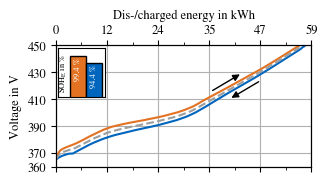

In [57]:
fig, axes= plt.subplots(1,1,figsize=(VisualizationConfig.columnwidth_in_in.value,
                                cm2inch(4)))

axes = plot_pOCV_vw(axes,
                          lst_dfs = [df_cupra_charge, df_cupra_discharge2],df_merge=df_merge_cupra)

In [58]:
def find_H2_peak(cap,dva,Q_min,Q_max):
    maskQ = (cap>Q_min)&(cap<Q_max)

    tmp_Q = cap[maskQ]
    tmp_dva = dva[maskQ]

    def func(x,a,b,c):
        return a*x**2 + b*x + c

    popt, pcov = curve_fit(func, tmp_Q, tmp_dva)

    return tmp_Q, func(tmp_Q, *popt)

In [59]:
def find_max_min(cap,dva,xmin,xmax,maximum=True):
    if maximum:
        ypos = np.max(dva[(cap>xmin)&(cap<xmax)])
    else:
        ypos = np.min(dva[(cap>xmin)&(cap<xmax)])
    xpos = cap[dva==ypos]
    return xpos[0], ypos

In [60]:
def plot_current_vw(axes, lst_dfs = []):
    
    for ind,data in enumerate(lst_dfs):
        curr_filt = FilterMethods().rolling_mean_df(lst_dfs[ind].I,window_size=FilterMethods().round_to_next_odd_number(len(lst_dfs[ind].I)*0.1/100))
        axes.plot(lst_dfs[ind].time_h,curr_filt,color=colors[ind],linewidth=1.5)
    
    axes.set_ylabel(r"Current in A",fontsize=9)
    axes.set_xlabel(r"Dis-/charging time in h",fontsize=9)
    axes.set_xlim([0,16])
    tick_positions = np.array([0,4,8,12,16])
    axes.set_xticks(tick_positions)
    axes.set_ylim([-20,20])
    tick_positions = np.array([-20,-10,0,10,20])
    axes.set_yticks(tick_positions)

    axes.grid(axis='both')
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)

    axes.annotate('power reduction', xy=(10.5, -2.5),
             xycoords='data',
             xytext=(2, -7.5),
             textcoords='data',
             bbox=dict(boxstyle="square,pad=0",facecolor='white', edgecolor='none'),
             arrowprops=dict(arrowstyle= '-|>',
                             color='k',
                             lw=1,
                             ls='-',shrinkA=1, shrinkB=0,facecolor="k", mutation_scale=10))
    return axes

In [61]:
def plot_current_vw_soc(axes, lst_dfs = []):
    
    for ind,data in enumerate(lst_dfs):
        curr_filt = FilterMethods().rolling_mean_df(lst_dfs[ind].I,window_size=FilterMethods().round_to_next_odd_number(len(lst_dfs[ind].I)*0.1/100))
        axes.plot(lst_dfs[ind].SOC,curr_filt,color=colors[ind],linewidth=1.5) # 96% BMS SOC = 100% UI SOC
    
    axes.set_ylabel(r"Current in A",fontsize=9)
    axes.set_xlabel(r"BMS-SOC in %",fontsize=9)
    axes.set_xlim([0,100])
    tick_positions = np.array([0,5,20,40,60,80,100])
    axes.set_xticks(tick_positions)
    axes.xaxis.set_minor_locator(FixedLocator([10,30,50,70,90]))
    axes.set_ylim([-20,20])
    tick_positions = np.array([-20,-10,0,10,20])
    axes.set_yticks(tick_positions)

    axes.grid(axis='both')
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)

    axes.annotate('power reduction', xy=(6, -5),
             xycoords='data',
             xytext=(22, -7),
             textcoords='data',
             bbox=dict(boxstyle="square,pad=0",facecolor='white', edgecolor='none'),
             arrowprops=dict(arrowstyle= '-|>',
                             color='k',
                             lw=1,
                             ls='-',shrinkA=1, shrinkB=0,facecolor="k", mutation_scale=10))
    return axes

C:\Users\Philip Bilfinger\AppData\Local\Temp\ipykernel_2440\2760325304.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  axes.annotate('power reduction', xy=(6, -5),


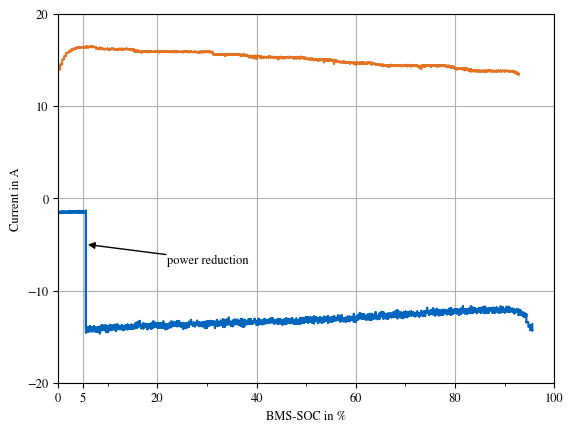

In [62]:
fig, axes= plt.subplots(1,1)
axes = plot_current_vw_soc(axes, lst_dfs =  [df_cupra_charge,df_cupra_discharge2])

In [63]:
def plot_dva_vw(axes,
                  lst_cap, lst_dva, cap_merge, dva_merge):
    color_ind =[0,1]
    Q_nom = 78*2
    for ind,data in enumerate(lst_cap):
        axes.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[color_ind[ind]], linewidth=1.5)
        xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=70, xmax=90, maximum=True)
        axes.scatter(xpos,ypos,marker="d",color=colors[color_ind[ind]],edgecolors="k",zorder=3)
    
    #xpos, ypos = find_max_min(lst_cap[0], lst_dva[0]*Q_nom, xmin=110, xmax=150, maximum=True)
    #axes.scatter(xpos,ypos,marker="o",color=colors[color_ind[0]],edgecolors="k",zorder=3)
    #axes.plot(cap_merge,dva_merge*Q_nom, color=VisualizationConfig.TUMgrau50.value, linewidth=1.5,linestyle="--")
    
    axes.set_ylabel(r"$Q_{N}\cdot \frac{dU}{dQ}$ in V",fontsize=9)
    axes.set_xlabel(r"Dis-/charged capacity in Ah",fontsize=9) 
    axes.set_xlim([0,150])
    tick_positions = np.array([0,30,60,90,120,150])
    axes.set_xticks(tick_positions)
    axes.set_ylim([0,162])
    tick_positions = np.array([0,0.5,1,1.5])*108
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    # Minor X-axis divided into 10 parts between each X-axis major grid
    axes.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.yaxis.set_label_coords(-0.11,0.5)
    
    twiny = axes.twiny() 
    twiny.set_xlim(0,150)
    tick_positions = np.array([0,30,60,90,120,150])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([15,45,75,105,135]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([])

    #insert axes left
    axins = axes.inset_axes([100, 10,45,70],transform = axes.transData) # [x0, y0, width, height]
    
    for ind,data in enumerate(lst_cap):
        axins.plot(lst_cap[ind],lst_dva[ind]*Q_nom, color=colors[color_ind[ind]], linewidth=1.5)
    xcap, yDVA = find_H2_peak(cap = lst_cap[0],dva = lst_dva[0]*Q_nom,Q_min=115,Q_max=145)
    maxDVA = np.argmax(yDVA)
    axins.scatter(xcap[maxDVA],yDVA[maxDVA],marker="o",color=colors[color_ind[0]],edgecolors="k",zorder=3)

    xcap, yDVA = find_H2_peak(cap = lst_cap[1],dva = lst_dva[1]*Q_nom,Q_min=115,Q_max=140)
    maxDVA = np.argmax(yDVA)
    axins.scatter(xcap[maxDVA],yDVA[maxDVA],marker="o",color=colors[color_ind[1]],edgecolors="k",zorder=3)
  
    # subregion of the original image
    x1, x2, y1, y2 = 115, 144, 108, 140
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    return axes

C:\Users\Philip Bilfinger\AppData\Local\Temp\ipykernel_2440\2760325304.py:24: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  axes.annotate('power reduction', xy=(6, -5),


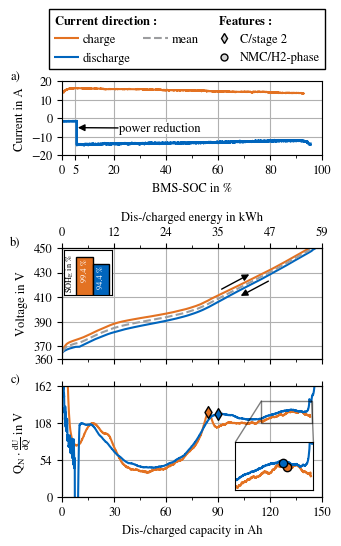

In [64]:
n_rows = 3
heigth = 4 #cm
gridspec = dict(hspace=0.0, height_ratios=[1, 0.01, 1.5, 1.5])
fig, axes= plt.subplots(n_rows+1,1,
                        figsize=(VisualizationConfig.columnwidth_in_in.value,
                                n_rows*cm2inch(heigth)),gridspec_kw=gridspec,constrained_layout=True)

axes[0] =  plot_current_vw_soc(axes[0], lst_dfs =  [df_cupra_charge,df_cupra_discharge2])
axes[1].set_visible(False)

axes[2] = plot_pOCV_vw(axes[2],
                          lst_dfs = [df_cupra_charge, df_cupra_discharge2],df_merge=df_merge_cupra)

axes[3] = plot_dva_vw(axes[3],
                          lst_cap = [cap_cupra_charge, cap_cupra_discharge+np.max(np.abs(cap_cupra_discharge))],
                          lst_dva = [dva_cupra_charge, dva_cupra_discharge],
                         cap_merge=cap_cupra_mean,dva_merge=dva_cupra_mean)



# plt.tight_layout()

axes[0].text(-0.2, 1.05, 'a)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=axes[0].transAxes)
axes[2].text(-0.2, 1.05, r'b)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=axes[2].transAxes)
axes[3].text(-0.2, 1.05, r'c)', horizontalalignment='left',fontsize=9,
      verticalalignment='center', transform=axes[3].transAxes)

# legend
handles, labels =axes[0].get_legend_handles_labels()  
line1 = plt.hlines(0,0,1,label="charge", color=colors[0])
line2 = plt.hlines(0,0,1,label="discharge", color=colors[1])
line3 = plt.hlines(0,0,1,label="mean", color=VisualizationConfig.TUMgrau50.value, linewidth=1.5,linestyle="--")
line4 = plt.hlines(0,0,1,label=" ", color="white")
marker1 =mlines.Line2D([], [], color='lightgray', marker='d',linestyle="None",markeredgecolor="k",
                          markersize=5, label=r'C/stage 2')
marker2 =  mlines.Line2D([], [], color='lightgray', marker='o',linestyle="None",markeredgecolor="k",
                          markersize=5, label=r'NMC/H2-phase')
lgd=fig.legend(handles=[line1,line2,line3,line4,marker1,marker2],loc="center",fontsize=9,ncols=3,handletextpad=0.3,
            framealpha =1 , fancybox=False,columnspacing=1,edgecolor="black",bbox_to_anchor=(0.55,1.06),title=r"$\bf{Current\ direction:}$"+"\t\t"+r"     $\bf{Features:}$",alignment='left')

fig.savefig(os.path.join(GeneralConfig.path2figures.value,"04-FIG-Roundtrip.pdf"),bbox_extra_artists=(lgd,), bbox_inches='tight') 
fig.savefig(os.path.join(GeneralConfig.path2figures.value,"04-FIG-Roundtrip.png"),dpi=300, pad_inches = 0) 

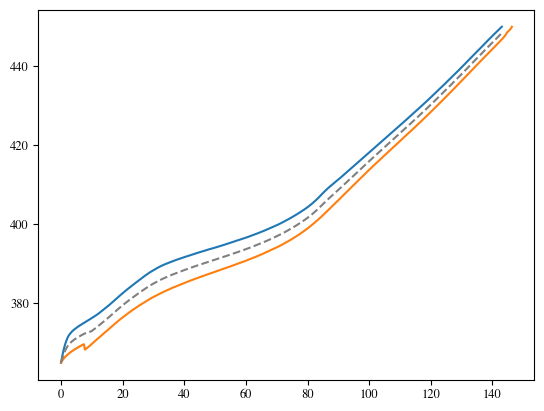

In [65]:
fig, axes= plt.subplots(1,1)
axes.plot(df_cupra_charge.Q,df_cupra_charge["U"],label="charge")
axes.plot(df_cupra_discharge.Q+np.max(np.abs(cap_cupra_discharge)),df_cupra_discharge["U"],label="discharge")
axes.plot(df_merge_cupra.Q,df_merge_cupra["U_mean"],label="mean",color="gray",linestyle="--")

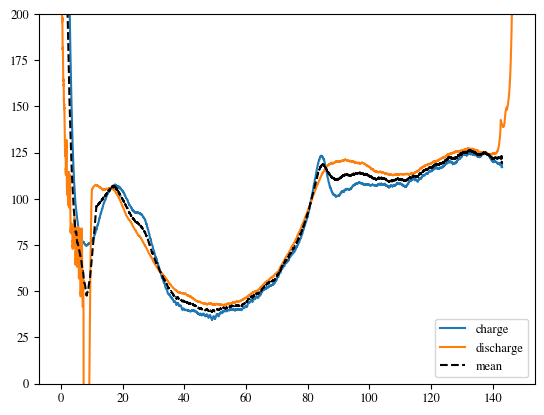

In [66]:
fig, axes= plt.subplots(1,1)
axes.plot(cap_cupra_charge,dva_cupra_charge*156,label="charge")
axes.plot(cap_cupra_discharge+np.max(np.abs(cap_cupra_discharge)),dva_cupra_discharge*156,label="discharge")
axes.plot(cap_cupra_mean,dva_cupra_mean*156,label="mean",color="k",linestyle="--")
plt.ylim(0,200)
plt.legend()

## Detect H2 Peak

(0.0, 1.0)

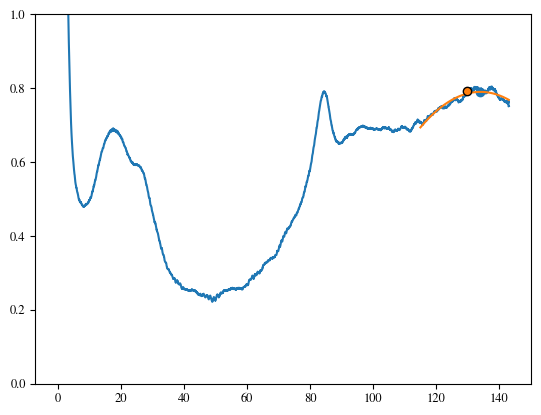

In [67]:
plt.plot(cap_cupra_charge,dva_cupra_charge)
Q,nDVA = find_H2_peak(cap_cupra_charge,dva_cupra_charge,Q_min=115,Q_max=145)
plt.plot(Q,nDVA)

maxDVA = np.argmax(nDVA)
plt.scatter(Q[maxDVA],nDVA[maxDVA])

xpos, ypos = find_max_min(cap_cupra_charge, dva_cupra_charge, xmin=110, xmax=130, maximum=True)
plt.scatter(xpos,ypos,marker="o",edgecolors="k",zorder=3)


plt.ylim(0,1)

(0.0, 1.0)

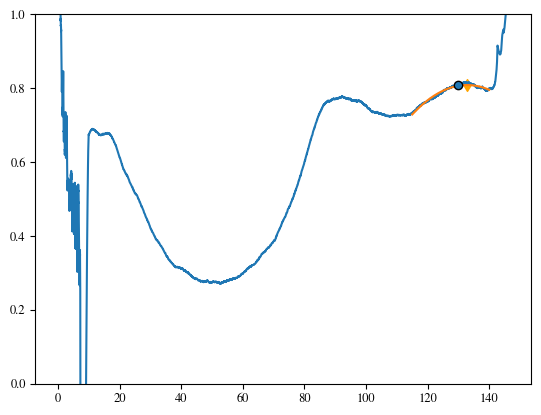

In [68]:
plt.plot(cap_cupra_discharge+np.max(np.abs(cap_cupra_discharge)),dva_cupra_discharge)
Q,nDVA = find_H2_peak(cap_cupra_discharge+np.max(np.abs(cap_cupra_discharge)),dva_cupra_discharge,Q_min=115,Q_max=140)
plt.plot(Q,nDVA)

maxDVA = np.argmax(nDVA)
plt.scatter(Q[maxDVA],nDVA[maxDVA],marker="d",color="orange")

xpos, ypos = find_max_min(cap_cupra_discharge+np.max(np.abs(cap_cupra_discharge)),dva_cupra_discharge, xmin=110, xmax=130, maximum=True)
plt.scatter(xpos,ypos,marker="o",edgecolors="k",zorder=3)


plt.ylim(0,1)